## Машинное обучение на больших данных с использованием фреймворка Apache Spark и библиотеки SparkML

#### Запуск `Spark`-сессии

Подключаем необходимые библиотеки.

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import GBTClassifier, GBTClassificationModel
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, CrossValidatorModel, ParamGridBuilder
from pyspark.ml import Pipeline
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col, when, udf, array, lit, explode, expr
from pyspark.ml.linalg import Vectors, VectorUDT
from sklearn.metrics import roc_curve, auc as sklearn_auc, RocCurveDisplay, accuracy_score, precision_score, recall_score, f1_score

Сформируем объект конфигурации для `Apache Spark`, указав необходимые параметры.

In [25]:
def create_spark_configuration() -> SparkConf:
    """
    Создает и конфигурирует экземпляр SparkConf для приложения Spark.

    Returns:
        SparkConf: Настроенный экземпляр SparkConf.
    """
    
    conf = SparkConf()
    conf.setAppName("Loan_GBT")
    conf.setMaster("local[*]")
    # conf.set("spark.submit.deployMode", "client")
    # КРИТИЧЕСКИЕ настройки памяти
    conf.set("spark.driver.memory", "10g")           
    conf.set("spark.executor.memory", "15g")         
    conf.set("spark.memory.fraction", "0.8")        
    conf.set("spark.memory.storageFraction", "0.3") 
    
    # Настройки для больших данных
    conf.set("spark.sql.adaptive.enabled", "true")
    conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
    conf.set("spark.sql.adaptive.skew.enabled", "true")
    conf.set("spark.sql.shuffle.partitions", "100")  # Уменьшил партиции

    return conf

Создаём сам объект конфигурации.

In [26]:
conf = create_spark_configuration()

Создаём и выводим на экран сессию `Apache Spark`. В процессе создания сессии происходит подключение к кластеру `Apache Hadoop`, что может занять некоторое время.

In [27]:
spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark

#### Загрузка датасета

In [28]:
database_name = "database"

test_data_name = 'test_data'
train_data_name = 'train_data'
path_test = f"{database_name}/{test_data_name}"
path_train = f"{database_name}/{train_data_name}"

test_df = spark.read.parquet(path_test)
train_df = spark.read.parquet(path_train)

def print_df(df):
    return df.limit(20).toPandas().style\
    .set_properties(**{'text-align': 'left', 'max-width': '0', 'white-space': 'nowrap', 'overflow': 'hidden', 'text-overflow': 'ellipsis'})\
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])\
    .format(precision=2)

In [29]:
train_df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- rn: short (nullable = true)
 |-- pre_since_opened: short (nullable = true)
 |-- pre_since_confirmed: short (nullable = true)
 |-- pre_pterm: short (nullable = true)
 |-- pre_fterm: short (nullable = true)
 |-- pre_till_pclose: short (nullable = true)
 |-- pre_till_fclose: short (nullable = true)
 |-- pre_loans_credit_limit: float (nullable = true)
 |-- pre_loans_next_pay_summ: float (nullable = true)
 |-- pre_loans_outstanding: float (nullable = true)
 |-- pre_loans_total_overdue: float (nullable = true)
 |-- pre_loans_max_overdue_sum: float (nullable = true)
 |-- pre_loans_credit_cost_rate: float (nullable = true)
 |-- pre_loans5: byte (nullable = true)
 |-- pre_loans530: byte (nullable = true)
 |-- pre_loans3060: byte (nullable = true)
 |-- pre_loans6090: byte (nullable = true)
 |-- pre_loans90: byte (nullable = true)
 |-- is_zero_loans5: byte (nullable = true)
 |-- is_zero_loans530: byte (nullable = true)
 |-- is_zero_loans3060: byte (nul

#### Постановка задачи

Для датасета, заданного представленными колонками, требуется построить модель градиентного бустинга на деревьях решений для оценки факта того, является ли отзыв полезным, по всем остальным признакам.

Для оценки качества обучения следует использовать метрики Precision и Recall. Оценить максимально возможное значение точности при полноте не менее 60%.

#### Подготовка и кодирование признаков

Для корректной работы трансформеров и модели преобразуем столбец `helpfulness_ratio` к типу `DoubleType`, а столбец `is_helpful` к типу `IntegerType`.

In [30]:
class PySparkCountAggregator:
    """Unified aggregator for categorical + numeric features by id for Spark GBT"""

    def __init__(self, categorical_columns):
        self.categorical_columns = categorical_columns

    def _encode_categories(self, df):
        """Fit & apply one-hot encoders"""
        stages = []
        encoded_cols = []

        for c in self.categorical_columns:
            idx = StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
            ohe = OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
            stages += [idx, ohe]
            encoded_cols.append(f"{c}_ohe")

        self.model = Pipeline(stages=stages).fit(df)
        df = self.model.transform(df)
        self.cat_ohe_cols = encoded_cols
        return df

    def fit_transform(self, df):
        df = self._encode_categories(df)
        return self._aggregate(df)

    def transform(self, df):
        assert hasattr(self, "model"), "Call fit_transform() first"
        df = self.model.transform(df)
        return self._aggregate(df)

    def _aggregate(self, df):
        """Aggregate everything by id"""
        
        # 1. numeric stats
        num_cols = [c for c in df.columns if c.startswith("pre_") or c == "rn"]

        agg_expr = []
        for c in num_cols:
            agg_expr += [
                F.mean(c).alias(f"{c}_mean"),
                F.max(c).alias(f"{c}_max"),
                F.min(c).alias(f"{c}_min"),
                F.stddev(c).alias(f"{c}_std"),
                (F.sum(when(col(c) == 0, 1).otherwise(0)) / F.count(c)).alias(f"{c}_zero_ratio"),
                F.count(c).alias(f"{c}_notnull_count"),
                F.expr(f"last({c}) - first({c})").alias(f"{c}_trend"),
                F.expr(f"percentile_approx({c}, 0.5)").alias(f"{c}_median")
            ]

        # 2. categorical sum via vector aggregation
        cat_cols = [c for c in df.columns if c.endswith("_ohe")]
        assembler = VectorAssembler(inputCols=cat_cols, outputCol="cat_vec")
        df = assembler.transform(df)

        # group by id
        agg_df = df.groupBy("id").agg(
            F.collect_list("cat_vec").alias("vectors_list"),
            *agg_expr,
            F.first("flag").alias("flag"),
            F.first("classWeight").alias("classWeight")
        )

        numeric_cols = [c for c in agg_df.columns if c not in ("id", "vectors_list", "flag", "classWeight", "cat_sum")]
        agg_df = agg_df.fillna(0, subset=numeric_cols)

        # sum collected vectors
        def sum_vecs(vecs):
            if not vecs:
                return Vectors.dense([])
            arr = sum(v.toArray() for v in vecs)
            return Vectors.dense(arr)

        sum_udf = udf(sum_vecs, VectorUDT())

        agg_df = agg_df.withColumn("cat_sum", sum_udf("vectors_list"))

        # assemble final features
        final_assembler = VectorAssembler(
            inputCols=["cat_sum"] + [c for c in agg_df.columns if c not in ("id", "vectors_list", "flag", "classWeight", "cat_sum", "cat_sum", "cat_sum")],
            outputCol="features"
        )

        agg_df = final_assembler.transform(agg_df)

        return agg_df.select("id", "features", "flag", "classWeight").cache()

In [31]:
# Определяем категориальные колонки (все enc_* колонки)
categorical_columns = [col for col in train_df.columns if col.startswith('enc_')]
print(f"Категориальных колонок: {len(categorical_columns)}")
print(categorical_columns[:10])  # Показать первые 10

Категориальных колонок: 29
['enc_paym_0', 'enc_paym_1', 'enc_paym_2', 'enc_paym_3', 'enc_paym_4', 'enc_paym_5', 'enc_paym_6', 'enc_paym_7', 'enc_paym_8', 'enc_paym_9']


Раскоментить, чтобы провести агрегацию при отсутствии сохраннёных агрегированных данных

In [32]:
# # Добавляем таргет
# train_target = spark.read.csv('../data/train_target.csv', header=True, inferSchema=True)
# train_data_target = train_df.join(train_target, on="id", how="inner")

# neg_count = train_data_target.filter(col("flag") == 0).count()
# pos_count = train_data_target.filter(col("flag") == 1).count()

# class_ratio = neg_count / pos_count  # во сколько раз 0 > 1

# train_data_target = train_data_target.withColumn(
#     "classWeight",
#     when(col("flag") == 1, class_ratio).otherwise(1.0)
# )

# print(f"Веса добавлены. ratio = {class_ratio:.2f}")

# # Шаг 1: Создаем агрегатор и обучаем на train
# train_aggregator = PySparkCountAggregator(categorical_columns)
# train_features = train_aggregator.fit_transform(train_data_target)

In [33]:
database_name = "database"
output_path = f"{database_name}/train_features"

Сохранение после агрегации, чтобы не повторять процесс

In [34]:
# print(f"Сохраняем данные в: {output_path}")
# train_features.write.mode("overwrite").option("compression", "snappy").parquet(output_path)
# print("Данные успешно сохранены в Parquet")

Загрузка агрегированных данных

In [35]:
train_features = spark.read.parquet(output_path)

In [40]:
train_features, valid_features = train_features.randomSplit([0.8, 0.2], seed=42)

Проведём взвешивание, чтобы не расширять датасет.

#### Обучение модели

In [41]:
train_features.printSchema()

root
 |-- id: integer (nullable = true)
 |-- features: vector (nullable = true)
 |-- flag: integer (nullable = true)
 |-- classWeight: double (nullable = true)



In [42]:
def train_gbt(train_df, label_col="flag"):
    """
    Очень простое обучение GBT на 32GB RAM + Ryzen 3700X.
    Минимальные настройки для стабильности.
    """

    gbt = GBTClassifier(
        featuresCol="features",
        labelCol="flag",
        weightCol="classWeight",
        maxIter=35,        
        maxDepth=5,
        subsamplingRate=0.6,
        featureSubsetStrategy="sqrt",
        maxBins=32,
        seed=42
    )

    
    print("Обучение GBT на всех данных...")
    model = gbt.fit(train_df)

    print("Обучение завершено.")
    return model


In [43]:
model = train_gbt(train_features)

Обучение GBT на всех данных...
Обучение завершено.


In [44]:
valid_pred = model.transform(valid_features)

# --- получаем probability и flag ---
prob_flag = valid_pred.select(
    vector_to_array(col("probability")).getItem(1).alias("p"),
    col("flag")
)

# --- создаём массив threshold'ов ---
thresholds = [t/100 for t in range(10, 91)]  # 0.10 ... 0.90
prob_flag = prob_flag.withColumn("thresholds", array(*[lit(t) for t in thresholds]))

# --- "взрываем" по threshold ---
exploded = prob_flag.select(
    "flag",
    "p",
    explode("thresholds").alias("t")
)

# --- делаем предсказание по threshold ---
exploded = exploded.withColumn("pred", (col("p") > col("t")).cast("int"))

# --- считаем TP, FP, FN по threshold ---
metrics = exploded.groupBy("t").agg(
    expr("sum(case when pred=1 and flag=1 then 1 else 0 end) as TP"),
    expr("sum(case when pred=1 and flag=0 then 1 else 0 end) as FP"),
    expr("sum(case when pred=0 and flag=1 then 1 else 0 end) as FN")
)

# --- добавляем precision и recall ---
metrics = metrics.withColumn("precision", col("TP") / (col("TP") + col("FP"))) \
                 .withColumn("recall", col("TP") / (col("TP") + col("FN")))

# --- фильтруем по recall ≥ 0.6 и выбираем лучший precision ---
best_row = metrics.filter(col("recall") >= 0.6) \
                  .orderBy(col("precision").desc()) \
                  .limit(1) \
                  .collect()[0]

print(f"Лучший threshold = {best_row['t']:.2f}, Precision = {best_row['precision']:.3f}, Recall = {best_row['recall']:.3f}")

Лучший threshold = 0.53, Precision = 0.068, Recall = 0.614


In [45]:
import time

# Замер времени
start_time = time.time()

# 1. Подготовка данных с оптимизацией
valid_df_opt = valid_features.cache()

valid_df_opt.count()  # Триггерим кэширование

# 2. Предсказание с мониторингом
print("Начинаем предсказание...")
valid_predictions = model.transform(valid_df_opt)

# Принудительный расчет и замер
valid_predictions.cache()
prediction_count = valid_predictions.count()
print(f"Рассчитано предсказаний: {prediction_count:,}")

# 3. Оценка метрик за один проход
print("Вычисление метрик...")

# AUC-ROC
evaluator = BinaryClassificationEvaluator(
    labelCol="flag",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = evaluator.evaluate(valid_predictions)
print(f"Validation AUC-ROC: {auc:.4f}")

def calculate_all_metrics(predictions: DataFrame):
    # Собираем все необходимые значения за один action
    preds_collected = predictions.select("flag", "prediction").collect()
    
    y_true = np.array([row.flag for row in preds_collected])
    y_pred = np.array([row.prediction for row in preds_collected])
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "weightedPrecision": precision_score(y_true, y_pred, average='weighted'),
        "weightedRecall": recall_score(y_true, y_pred, average='weighted'),
        "f1": f1_score(y_true, y_pred, average='weighted')
    }
    
    return metrics

metrics = calculate_all_metrics(valid_predictions)
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

print(f"Общее время выполнения: {time.time() - start_time:.2f} секунд")

# 4. Очистка кэша (если нужно)
valid_df_opt.unpersist()
valid_predictions.unpersist()

Начинаем предсказание...
Рассчитано предсказаний: 245,990
Вычисление метрик...
Validation AUC-ROC: 0.7128
accuracy: 0.6363
weightedPrecision: 0.9489
weightedRecall: 0.6363
f1: 0.7478
Общее время выполнения: 22.71 секунд


DataFrame[id: int, features: vector, flag: int, classWeight: double, rawPrediction: vector, probability: vector, prediction: double]

Построение ROC кривой с sklearn...


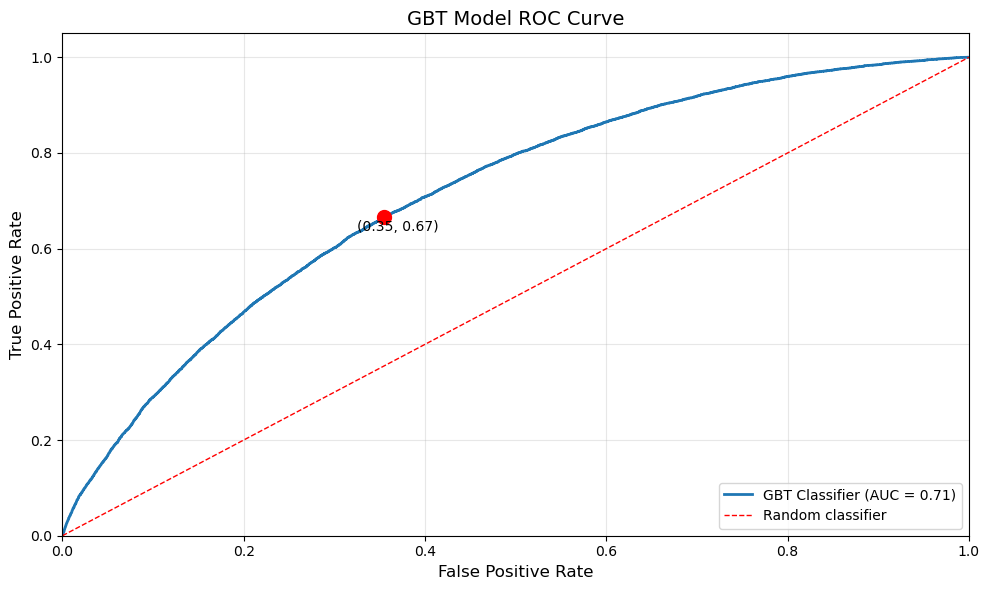

AUC: 0.7128
Best threshold: 0.5053
Best TPR: 0.6662
Best FPR: 0.3548


In [46]:
def plot_roc_with_sklearn(predictions, label_col="flag", title="ROC Curve"):
    """
    Использование sklearn для построения ROC
    """
    # Конвертируем в pandas для sklearn
    probs_labels = predictions.select(
        vector_to_array(col("probability")).getItem(1).alias("probability"),
        col(label_col).alias("label")
    ).toPandas()
    
    y_true = probs_labels["label"].values
    y_score = probs_labels["probability"].values
    
    # Вычисляем ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = sklearn_auc(fpr, tpr)
    
    # Построение
    fig, ax = plt.subplots(figsize=(10, 6))
    roc_display = RocCurveDisplay(
        fpr=fpr, 
        tpr=tpr, 
        roc_auc=roc_auc,
        estimator_name="GBT Classifier"
    )
    
    roc_display.plot(ax=ax, linewidth=2)
    
    # Добавляем диагональ
    ax.plot([0, 1], [0, 1], 'r--', label='Random classifier', linewidth=1)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    
    # Показываем лучший threshold (ближайший к верхнему левому углу)
    gmeans = np.sqrt(tpr * (1 - fpr))
    ix = np.argmax(gmeans)
    best_threshold = thresholds[ix]
    
    ax.plot(fpr[ix], tpr[ix], 'ro', markersize=10, 
            label=f'Best threshold = {best_threshold:.3f}')
    ax.annotate(f'({fpr[ix]:.2f}, {tpr[ix]:.2f})', 
                (fpr[ix], tpr[ix]), 
                textcoords="offset points", 
                xytext=(10,-10), 
                ha='center')
    
    plt.tight_layout()
    plt.show()
    
    print(f"AUC: {roc_auc:.4f}")
    print(f"Best threshold: {best_threshold:.4f}")
    print(f"Best TPR: {tpr[ix]:.4f}")
    print(f"Best FPR: {fpr[ix]:.4f}")
    
    return roc_auc, fpr, tpr, best_threshold

# Использование:
print("Построение ROC кривой с sklearn...")
auc_score, fpr, tpr, best_threshold = plot_roc_with_sklearn(
    valid_predictions,
    title="GBT Model ROC Curve"
)

In [47]:
import shutil
import os

def save_model(model, path="models/my_model", overwrite=True):
    """
    Сохраняет модель с обработкой существующих файлов
    """
    if overwrite:
        # Удаляем старую модель, если существует
        if os.path.exists(path):
            print(f"Удаляю старую модель: {path}")
            shutil.rmtree(path, ignore_errors=True)
    
    # Сохраняем новую модель
    model.save(path)
    print(f"Модель сохранена: {path}")
    return path

# Использование
save_model(model, "models/my_model")

Удаляю старую модель: models/my_model
Модель сохранена: models/my_model


'models/my_model'

Не забываем завершать `Spark`-сессию.

In [48]:
spark.stop()